In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

path=os.getcwd()

df = pd.read_excel(f'{path}\\Dataset.xlsx', usecols=['Fecha', 'P','G(i)','H_sun','T2m','WS10m','Int'])

print(df)

                  Fecha    P  G(i)  H_sun   T2m  WS10m  Int
0      2017-01-01 00:01  0.0   0.0    0.0  4.59   2.07  0.0
1      2017-01-01 01:01  0.0   0.0    0.0  4.57   2.07  0.0
2      2017-01-01 02:01  0.0   0.0    0.0  4.76   1.93  0.0
3      2017-01-01 03:01  0.0   0.0    0.0  5.34   1.79  0.0
4      2017-01-01 04:01  0.0   0.0    0.0  5.09   1.79  0.0
...                 ...  ...   ...    ...   ...    ...  ...
35059  2020-12-31 19:01  0.0   0.0    0.0  7.86   4.34  0.0
35060  2020-12-31 20:01  0.0   0.0    0.0  7.75   3.79  0.0
35061  2020-12-31 21:01  0.0   0.0    0.0  7.69   3.24  0.0
35062  2020-12-31 22:01  0.0   0.0    0.0  7.66   3.03  0.0
35063  2020-12-31 23:01  0.0   0.0    0.0  7.54   3.59  0.0

[35064 rows x 7 columns]


In [2]:
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y-%m-%d %H:%M')
df = df.set_index('Fecha')
df = df.asfreq('H', method='ffill')
df = df.sort_index()
df.head()

C:\Users\Noel\AppData\Local\Temp\ipykernel_21724\2394605671.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.asfreq('H', method='ffill')


,P,G(i),H_sun,T2m,WS10m,Int
Fecha,,,,,,
2017-01-01 00:01:00,0.0,0.0,0.0,4.59,2.07,0.0
2017-01-01 01:01:00,0.0,0.0,0.0,4.57,2.07,0.0
2017-01-01 02:01:00,0.0,0.0,0.0,4.76,1.93,0.0
2017-01-01 03:01:00,0.0,0.0,0.0,5.34,1.79,0.0
2017-01-01 04:01:00,0.0,0.0,0.0,5.09,1.79,0.0


In [3]:
year=24*3600*365.25
seconds=df.index.map(pd.Timestamp.timestamp)
day=24*3600

df['day_sin']=np.sin(seconds*(2*np.pi/day))
df['day_cos']=np.cos(seconds*(2*np.pi/day))
df['year_sin']=np.sin(seconds*(2*np.pi/year))
df['year_cos']=np.cos(seconds*(2*np.pi/year))

df = df.reset_index()
df=df.drop(columns=['Fecha'])
df.drop(columns=['G(i)'], inplace=True)
df = df.dropna()
df= df.loc[:, df.std() > 0]


In [4]:
#Divide data into train, validation and test sets

def train_val_test_split(dataframe, tr_size=0.8, vl_size=0.1, ts_size=0.1 ):
    N = dataframe.shape[0]
    Ntrain = int(tr_size*N)  # Training data
    Nval = int(vl_size*N)    # Validation data


    train = dataframe[0:Ntrain]
    val = dataframe[Ntrain:Ntrain+Nval]
    test = dataframe[Ntrain+Nval:]

    return train, val, test


train,val,test = train_val_test_split(df)

print(f'Train shape: {train.shape}')
print(f'Validation shape: {val.shape}')
print(f'Test shape: {test.shape}')

Train shape: (28051, 8)
Validation shape: (3506, 8)
Test shape: (3507, 8)


In [5]:
from sklearn.preprocessing import StandardScaler

def escalar_dataset(data_train,data_validation,data_test, col_ref):

  NFEATS = data_train.shape[1]

  # List of scalers for each feature
  scalers = [StandardScaler() for _ in range(NFEATS)]

  data_t = np.zeros(data_train.shape)
  data_v = np.zeros(data_validation.shape)
  data_ts = np.zeros(data_test.shape)

  for i, scaler in enumerate(scalers):
      
    data_i = data_train.iloc[:, i].values.reshape(-1, 1)
    data_t[:, i] = scaler.fit_transform(data_i).flatten()

    # Scale data for validation
    data_j = data_validation.iloc[:, i].values.reshape(-1, 1)
    data_v[:, i] = scaler.transform(data_j).flatten()

    # Scale data for test
    data_k = data_test.iloc[:, i].values.reshape(-1, 1)
    data_ts[:, i] = scaler.transform(data_k).flatten()

  return data_t,data_v,data_ts, scalers[data_train.columns.get_loc(col_ref)]

In [6]:
#Save the date columns before scaling
save_col1 = train[['day_sin', 'day_cos', 'year_sin', 'year_cos']].copy()
save_col1.reset_index(drop=True, inplace=True)
save_col1.index += 0

save_col2 = val[['day_sin', 'day_cos', 'year_sin', 'year_cos']].copy()

save_col2.reset_index(drop=True, inplace=True)
save_col2.index += 0

save_col3 = test[['day_sin', 'day_cos', 'year_sin', 'year_cos']].copy()

save_col3.reset_index(drop=True, inplace=True)
save_col3.index += 0

# Scale dataset
tr, vl, ts, scaler = escalar_dataset(train, val, test, col_ref='P')

# Convert results to DataFrame
tr = pd.DataFrame(tr, columns=list(df.columns.values))
vl = pd.DataFrame(vl, columns=list(df.columns.values))
ts = pd.DataFrame(ts, columns=list(df.columns.values))

# Restore the date columns after scaling
tr[['day_sin', 'day_cos', 'year_sin', 'year_cos']] = save_col1
vl[['day_sin', 'day_cos', 'year_sin', 'year_cos']] = save_col2
ts[['day_sin', 'day_cos', 'year_sin', 'year_cos']] = save_col3

In [7]:
def crear_dataset_supervisado(array, input_length, output_length):

    X, Y = [], [] 
    fils, cols = array.shape # This is done this way because we have several series (multivariate)

    # Generate the arrays
    for i in range(fils-input_length-output_length):
        #Model input
        X.append(array[i:i+INPUT_LENGTH,0:cols])

        Y.append(array[i+input_length:i+input_length+output_length,0].reshape(output_length,1))

    X = np.array(X)
    Y = np.array(Y)

    return X, Y

In [8]:
# Create datasets for training, validation and testing
INPUT_LENGTH = 24    
OUTPUT_LENGTH = 1    

x_tr, y_tr = crear_dataset_supervisado(tr.values, INPUT_LENGTH, OUTPUT_LENGTH)
x_vl, y_vl = crear_dataset_supervisado(vl.values, INPUT_LENGTH, OUTPUT_LENGTH)
x_ts, y_ts = crear_dataset_supervisado(ts.values, INPUT_LENGTH, OUTPUT_LENGTH)

# Imprimir información en pantalla
print('Input shape (BATCHES x INPUT_LENGTH x FEATURES) and output(BATCHES x OUTPUT_LENGTH x FEATURES)')
print(f'Train set - x_tr: {x_tr.shape}, y_tr: {y_tr.shape}')
print(f'Validation set - x_vl: {x_vl.shape}, y_vl: {y_vl.shape}')
print(f'Test set - x_ts: {x_ts.shape}, y_ts: {y_ts.shape}')

Input shape (BATCHES x INPUT_LENGTH x FEATURES) and output(BATCHES x OUTPUT_LENGTH x FEATURES)
Train set - x_tr: (28026, 24, 8), y_tr: (28026, 1, 1)
Validation set - x_vl: (3481, 24, 8), y_vl: (3481, 1, 1)
Test set - x_ts: (3482, 24, 8), y_ts: (3482, 1, 1)


In [9]:
import numpy as np

# ── Parámetros ────────────────────────────────────────────────────────────────
WINDOW       = 24
N_FEATURES   = x_tr.shape[2]

# Índices de las features (ajusta según tu orden de columnas)
IDX_CICLICAS = [ 4, 5, 6, 7]   # day_sin, day_cos, year_sin, year_cos
IDX_LAGS     = [0, 1, 2, 3]   # P, H_sun, T2m, WS10m (las que sí tienen lags)

def build_xgb_input(X_3d):
    """
    X_3d: (n_samples, window, n_features)
    Devuelve X_2d: (n_samples, n_features_xgb)
    
    - Features cíclicas: solo el último timestep (valor actual)
    - Features con lags: todos los timesteps de la ventana
    """
    n = X_3d.shape[0]
    
    # Solo el último paso temporal para cíclicas (1 valor por feature)
    ciclicas = X_3d[:, -1, :][:, IDX_CICLICAS]  # (n, 4)
    
    # Todos los timesteps para features con lags
    lags = X_3d[:, :, :][:, :, IDX_LAGS].reshape(n, -1)  # (n, window * n_lag_features)
    
    return np.concatenate([ciclicas, lags], axis=1)

X_tr_xgb = build_xgb_input(x_tr)
X_vl_xgb = build_xgb_input(x_vl)
X_ts_xgb = build_xgb_input(x_ts)

print(f"Shape original : {x_tr.shape}")
print(f"Shape XGBoost  : {X_tr_xgb.shape}")

Shape original : (28026, 24, 8)
Shape XGBoost  : (28026, 100)


In [12]:
from xgboost import XGBRegressor

model_XGB = XGBRegressor(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    early_stopping_rounds=25,
    reg_lambda=1.0,
    objective='reg:squarederror',
    eval_metric='rmse',
    device='cuda',
    random_state=42,
    n_jobs=-1
)
model_XGB.fit(X_tr_xgb, y_tr.reshape(-1, 1), eval_set=[(X_vl_xgb, y_vl.reshape(-1, 1))], verbose=10)
model_XGB.save_model("model_XGB.json")

[0]	validation_0-rmse:1.08841
[10]	validation_0-rmse:0.83828
[20]	validation_0-rmse:0.65886
[30]	validation_0-rmse:0.53375
[40]	validation_0-rmse:0.45076
[50]	validation_0-rmse:0.39618
[60]	validation_0-rmse:0.36257
[70]	validation_0-rmse:0.34151
[80]	validation_0-rmse:0.32888
[90]	validation_0-rmse:0.32125
[100]	validation_0-rmse:0.31686
[110]	validation_0-rmse:0.31420
[120]	validation_0-rmse:0.31272
[130]	validation_0-rmse:0.31180
[140]	validation_0-rmse:0.31135
[150]	validation_0-rmse:0.31103
[160]	validation_0-rmse:0.31078
[170]	validation_0-rmse:0.31046
[180]	validation_0-rmse:0.31063
[190]	validation_0-rmse:0.31047
[200]	validation_0-rmse:0.31057
[210]	validation_0-rmse:0.31049
[217]	validation_0-rmse:0.31058


In [13]:
import xgboost as xgb

model_XGB = xgb.XGBRegressor()
model_XGB.load_model("model_XGB.json")

In [14]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_xgb = model_XGB.predict(X_ts_xgb)

y_real = scaler.inverse_transform(y_ts.reshape(-1, 1)).flatten()
y_pred = scaler.inverse_transform(y_pred_xgb.reshape(-1, 1)).flatten()

def mask_night(real):
    n = len(real)
    keep = np.zeros(n, dtype=bool)
    for i in range(n):
        if real[i] != 0:
            keep[i] = True
        else:
            prev_nonzero = (i > 0)     and (real[i-1] != 0)
            next_nonzero = (i < n-1)   and (real[i+1] != 0)
            keep[i] = prev_nonzero or next_nonzero
    return keep

mask = mask_night(y_real)
y_real_m = y_real[mask]
y_pred_m = y_pred[mask]

mask_n = mask[:-1] & mask[1:]  

#Naïve (persistence) with the same mask
y_naive_m  = y_real[:-1][mask_n]
y_true_n_m = y_real[1:][mask_n]
y_pred_n_m = y_pred[1:][mask_n]


def mMAPE(real, pred):
    y_max = np.max(np.abs(real))
    if y_max < 1:
        return 100 * np.mean(np.abs(real - pred))
    return 100 * np.mean(np.abs(real - pred) / y_max)

def forecast_skill(real, pred, naive):
    rmse_model = np.sqrt(mean_squared_error(real, pred))
    rmse_naive = np.sqrt(mean_squared_error(real, naive))
    return 1 - (rmse_model / rmse_naive)

mse  = mean_squared_error(y_real_m, y_pred_m)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_real_m, y_pred_m)
r2   = r2_score(y_real_m, y_pred_m)
mape = mMAPE(y_real_m, y_pred_m)
fs   = forecast_skill(y_true_n_m, y_pred_n_m, y_naive_m)

print(f"MSE   : {mse:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"MAE   : {mae:.4f}")
print(f"R²    : {r2:.4f}")
print(f"mMAPE : {mape:.4f}%")
print(f"FS    : {fs:.4f}")

MSE   : 10832.6310
RMSE  : 104.0799
MAE   : 64.2994
R²    : 0.8017
mMAPE : 7.8312%
FS    : 0.2840


In [15]:
# Metrics Naïve complete
mse_n  = mean_squared_error(y_true_n_m, y_naive_m)
rmse_n = np.sqrt(mse_n)
mae_n  = mean_absolute_error(y_true_n_m, y_naive_m)
r2_n   = r2_score(y_true_n_m, y_naive_m)
mape_n = mMAPE(y_true_n_m, y_naive_m)

# Compare metrics in a table 
metrics = ["MSE", "RMSE", "MAE", "R²", "mMAPE (%)", "FS"]
XGB_vals   = [mse,   rmse,   mae,   r2,   mape,   fs]
naive_vals = [mse_n, rmse_n, mae_n, r2_n, mape_n, None]

print("=" * 50)
print(f"{'Metric':<12} {'XGB':>12} {'Naïve':>12}")
print("=" * 50)
for m, x, n in zip(metrics, XGB_vals, naive_vals):
    x_str = f"{x:.4f}"
    n_str = f"{n:.4f}" if n is not None else "N/A"
    # Ok if XGB is better (lower MSE, RMSE, MAE, mMAPE; higher R²; higher FS)
    if n is not None:
        better = x < n if m != "R²" else x > n
        flag = " OK" if better else " NO"
    else:
        flag = ""
    print(f"{m:<12} {x_str:>12} {n_str:>12}{flag}")
print("=" * 50)
print(f"{'FS > 0 → XGB overperforms Naïve':>50}")
print(f"{'FS < 0 → Naïve is better':>50}")
print("=" * 50)

Metric                XGB        Naïve
MSE            10832.6310   22991.5198 OK
RMSE             104.0799     151.6295 OK
MAE               64.2994     111.9514 OK
R²                 0.8017       0.5778 OK
mMAPE (%)          7.8312      13.6348 OK
FS                 0.2840          N/A
                   FS > 0 → XGB overperforms Naïve
                          FS < 0 → Naïve is better


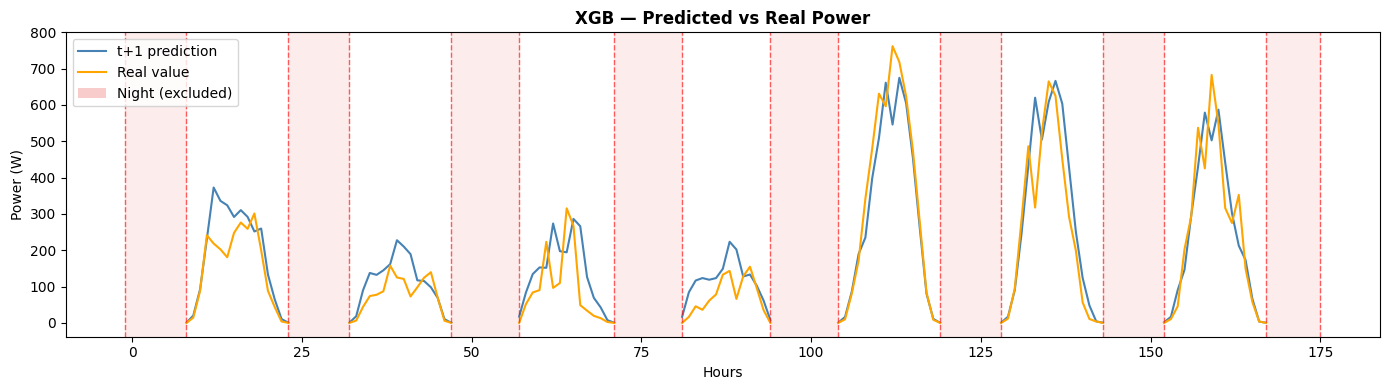

In [16]:
import numpy as np
import matplotlib.pyplot as plt
hpredic = 175

y_real_plot = y_real[:hpredic].flatten()
y_pred_plot = y_pred[:hpredic].flatten()

def insert_nan_nights(real, pred):
    n = len(real)
    r = real.copy().astype(float)
    p = pred.copy().astype(float)
    for i in range(n):
        if real[i] == 0:
            prev_nonzero = (i > 0)   and (real[i-1] != 0)
            next_nonzero = (i < n-1) and (real[i+1] != 0)
            if not (prev_nonzero or next_nonzero):
                r[i] = np.nan
                p[i] = np.nan
    return r, p

y_real_clean, y_pred_clean = insert_nan_nights(y_real_plot, y_pred_plot)

is_nan  = np.isnan(y_real_clean)
n       = len(is_nan)
night_blocks = []
i = 0
while i < n:
    if is_nan[i]:
        start = i
        while i < n and is_nan[i]:
            i += 1
        night_blocks.append((start-1, i))
    else:
        i += 1

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(y_pred_clean, label='t+1 prediction', color='steelblue', lw=1.5)
ax.plot(y_real_clean, label='Real value',      color='orange',    lw=1.5)


for start, end in night_blocks:
    ax.axvspan(start, end, color='lightcoral', alpha=0.15, zorder=0)
    ax.axvline(x=start, color='red', lw=1.0, linestyle='--', alpha=0.6)
    ax.axvline(x=end,   color='red', lw=1.0, linestyle='--', alpha=0.6)

from matplotlib.patches import Patch
night_patch = Patch(facecolor='lightcoral', alpha=0.4, label='Night (excluded)')
ax.legend(handles=[
    plt.Line2D([0],[0], color='steelblue', lw=1.5, label='t+1 prediction'),
    plt.Line2D([0],[0], color='orange',    lw=1.5, label='Real value'),
    night_patch
])

ax.set_xlabel('Hours')
ax.set_ylabel('Power (W)')
ax.set_title('XGB — Predicted vs Real Power', fontweight='bold')
plt.tight_layout()
plt.show()

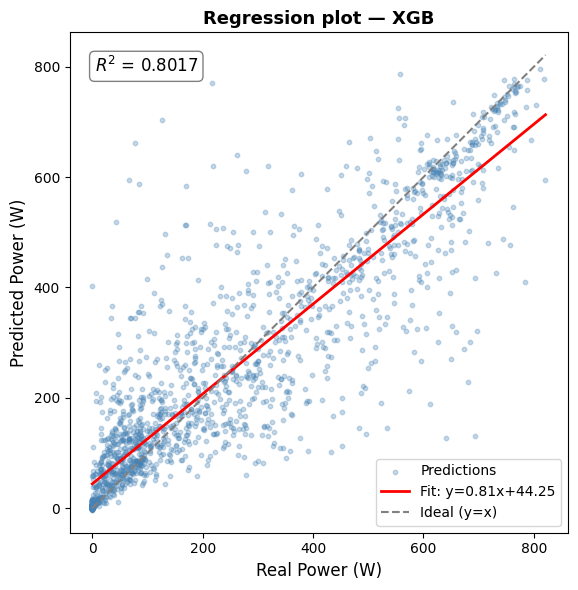

R²     : 0.8017
Slope  : 0.8145
Intercept: 44.2537


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score


m, b = np.polyfit(y_real_m.flatten(), y_pred_m.flatten(), 1)
r2   = r2_score(y_real_m.flatten(), y_pred_m.flatten())


fig, ax = plt.subplots(figsize=(6, 6))

# Points
ax.scatter(y_real_m, y_pred_m, alpha=0.3, s=10, color='steelblue', label='Predictions')

# Regression line
x_line = np.linspace(y_real_m.min(), y_real_m.max(), 200)
ax.plot(x_line, m * x_line + b, color='red', lw=2, label=f'Fit: y={m:.2f}x+{b:.2f}')

# Ideal line
ax.plot(x_line, x_line, color='gray', lw=1.5, linestyle='--', label='Ideal (y=x)')

# R² annotation
ax.text(0.05, 0.92, f'$R^2$ = {r2:.4f}',
        transform=ax.transAxes, fontsize=12,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))

ax.set_xlabel('Real Power (W)', fontsize=12)
ax.set_ylabel('Predicted Power (W)', fontsize=12)
ax.set_title('Regression plot — XGB', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print(f"R²     : {r2:.4f}")
print(f"Slope  : {m:.4f}")
print(f"Intercept: {b:.4f}")

In [ ]:
def pfi_xgb_3d(model, X_3d, y, col_names, idx_ciclicas, idx_lags, window):
    from sklearn.metrics import mean_absolute_error
    resultados = []

    X_2d_orig   = build_xgb_input(X_3d)
    y_pred_orig = scaler.inverse_transform(model.predict(X_2d_orig).reshape(-1,1)).flatten()  # ← inverse_transform
    mae_orig    = mean_absolute_error(y, y_pred_orig)

    all_idx = idx_ciclicas + idx_lags

    for k in all_idx:
        name = col_names[k]
        print(f'Calculando PFI para {name}...')

        X_perm = X_3d.copy()

        if k in idx_ciclicas:
            np.random.shuffle(X_perm[:, -1, k])
        else:
            for t in range(window):
                np.random.shuffle(X_perm[:, t, k])

        X_2d_perm = build_xgb_input(X_perm)
        y_pred_perm = scaler.inverse_transform(model.predict(X_2d_perm).reshape(-1,1)).flatten()  # ← inverse_transform
        mae_perm  = mean_absolute_error(y, y_pred_perm)
        pfi       = mae_perm / mae_orig

        resultados.append({'feature': name, 'feature_importance': pfi})
        print(f'  {name}: PFI={pfi:.4f}')

    return pd.DataFrame(resultados).sort_values(
        'feature_importance', ascending=False)

# ── Llamada ───────────────────────────────────────────────────────────────────
col_names = list(tr.columns)

fi_xgb = pfi_xgb_3d(
    model        = model_XGB,    # ← model_XGB, no model
    X_3d         = x_ts,
    y            = scaler.inverse_transform(y_ts.reshape(-1,1)).flatten(),
    col_names    = col_names,
    idx_ciclicas = IDX_CICLICAS,
    idx_lags     = IDX_LAGS,
    window       = WINDOW
)
print(fi_xgb)

Calculando PFI para day_sin...
  day_sin: PFI=1.0537
Calculando PFI para day_cos...
  day_cos: PFI=1.3039
Calculando PFI para year_sin...
  year_sin: PFI=1.0011
Calculando PFI para year_cos...
  year_cos: PFI=1.0011
Calculando PFI para P...
  P: PFI=3.9491
Calculando PFI para H_sun...
  H_sun: PFI=1.9774
Calculando PFI para T2m...
  T2m: PFI=1.0282
Calculando PFI para WS10m...
  WS10m: PFI=1.0337
    feature  feature_importance
4         P            3.949056
5     H_sun            1.977418
1   day_cos            1.303929
0   day_sin            1.053660
7     WS10m            1.033663
6       T2m            1.028223
3  year_cos            1.001143
2  year_sin            1.001115


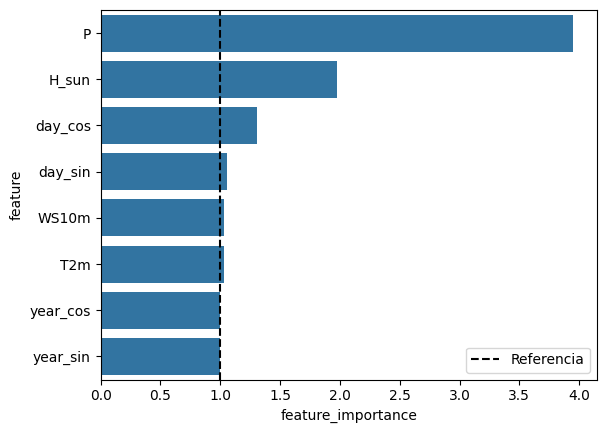

In [ ]:
import seaborn as sns

ax = sns.barplot(data=fi_xgb, x='feature_importance', y='feature')
ax.axvline(1.0, color='k', linestyle='--', label='Referencia')
ax.legend();